# import libraries

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler  

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Load Dataset

In [61]:
df = pd.read_csv("customer_churn_sample.csv")
print("Data loaded Successfully!")

Data loaded Successfully!


In [62]:
df.head()

,customerID,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,CUST1,Male,1,12,74.26,3923.48,Month-to-month,Fiber optic,Credit card (automatic),Yes
1,CUST2,Female,1,60,86.21,4610.42,Two year,DSL,Electronic check,No
2,CUST3,Male,1,50,49.82,711.46,Month-to-month,DSL,Electronic check,No
3,CUST4,Female,1,54,97.72,1125.98,Two year,No,Mailed check,Yes
4,CUST5,Female,1,47,112.67,2282.90,Two year,No,Bank transfer (automatic),Yes


# insights
- High-paying customers are at higher risk of churn
- New customers need more attention and engagement
- Long-term contracts help reduce churn significantly
- Pricing and service quality are key factors
- Retention strategies (discounts, offers) can reduce churn

# Data Cleaning

In [63]:
# dropping the unnessary column customerId is not useful
df = df.drop("customerID",axis=1)

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           200 non-null    str    
 1   SeniorCitizen    200 non-null    int64  
 2   tenure           200 non-null    int64  
 3   MonthlyCharges   200 non-null    float64
 4   TotalCharges     200 non-null    float64
 5   Contract         200 non-null    str    
 6   InternetService  200 non-null    str    
 7   PaymentMethod    200 non-null    str    
 8   Churn            200 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 14.2 KB


In [65]:
df.describe

<bound method NDFrame.describe of      gender  SeniorCitizen  tenure  MonthlyCharges  TotalCharges  \
0      Male              1      12           74.26       3923.48   
1    Female              1      60           86.21       4610.42   
2      Male              1      50           49.82        711.46   
3    Female              1      54           97.72       1125.98   
4    Female              1      47          112.67       2282.90   
..      ...            ...     ...             ...           ...   
195    Male              0      11           37.04       5521.88   
196    Male              0      25           77.59       4118.25   
197    Male              1      52          101.90       2181.65   
198    Male              0      17           30.98       4043.19   
199    Male              1      13          114.38       6566.98   

           Contract InternetService              PaymentMethod Churn  
0    Month-to-month     Fiber optic    Credit card (automatic)   Yes  
1      

In [66]:
# Convert 'TotalCharges' from object (text) to numeric
# errors='coerce' will convert invalid values to NaN

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

#remove rows with missing values
df = df.dropna()

print("\n After Cleaning: ")
df.info()


 After Cleaning: 
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           200 non-null    str    
 1   SeniorCitizen    200 non-null    int64  
 2   tenure           200 non-null    int64  
 3   MonthlyCharges   200 non-null    float64
 4   TotalCharges     200 non-null    float64
 5   Contract         200 non-null    str    
 6   InternetService  200 non-null    str    
 7   PaymentMethod    200 non-null    str    
 8   Churn            200 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 14.2 KB


### convert categorical data to numeric 

In [67]:
# column churn to numeric
df['Churn'] = df['Churn'].map({"Yes":1, "No":0})

# Convert all other categorical columns using one-hot encoding
#drop_First = True is remove the duplicates columns

df = pd.get_dummies(df, drop_first=True)

In [68]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,12,74.26,3923.48,1,True,False,False,True,False,True,False,False
1,1,60,86.21,4610.42,0,False,False,True,False,False,False,True,False
2,1,50,49.82,711.46,0,True,False,False,False,False,False,True,False
3,1,54,97.72,1125.98,1,False,False,True,False,True,False,False,True
4,1,47,112.67,2282.90,1,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,11,37.04,5521.88,1,True,True,False,False,True,False,True,False
196,0,25,77.59,4118.25,1,True,False,False,False,True,False,False,True
197,1,52,101.90,2181.65,1,True,False,True,True,False,True,False,False
198,0,17,30.98,4043.19,0,True,True,False,False,False,False,False,True


In [69]:
print("\nAfter Encoding:")
print(df.head())



After Encoding:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              1      12           74.26       3923.48      1         True   
1              1      60           86.21       4610.42      0        False   
2              1      50           49.82        711.46      0         True   
3              1      54           97.72       1125.98      1        False   
4              1      47          112.67       2282.90      1        False   

   Contract_One year  Contract_Two year  InternetService_Fiber optic  \
0              False              False                         True   
1              False               True                        False   
2              False              False                        False   
3              False               True                        False   
4              False               True                        False   

   InternetService_No  PaymentMethod_Credit card (automatic)  \
0               F

# Split Features and Target

In [70]:
# X = input except churn
X = df.drop("Churn",axis = 1)

# y = Churn column
y = df["Churn"]

In [71]:
# Convert boolean → int
X = X.astype(int)

# Train TEst split

In [72]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2)

In [73]:
print("Before scaling:")
print(X.head())
print(X.dtypes)

Before scaling:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              1      12              74          3923            1   
1              1      60              86          4610            0   
2              1      50              49           711            1   
3              1      54              97          1125            0   
4              1      47             112          2282            0   

   Contract_One year  Contract_Two year  InternetService_Fiber optic  \
0                  0                  0                            1   
1                  0                  1                            0   
2                  0                  0                            0   
3                  0                  1                            0   
4                  0                  1                            0   

   InternetService_No  PaymentMethod_Credit card (automatic)  \
0                   0                                      1

# Feature scaling

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)

# Only transform test data
X_test = scaler.transform(X_test)


# Train Models

# Logistic Regression

In [75]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Random Forest Model 

In [76]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Predictions

In [77]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [78]:
print(X_test)
print(type(X_test))

[[ 0.98757716 -0.38807403  0.50252064  1.450083   -1.02532046  1.4832397
  -0.77459667  1.34425353 -0.74390729  1.82327297 -0.53881591 -0.58697344]
 [ 0.98757716  1.22208727  1.54717161 -1.04004217  0.97530483  1.4832397
  -0.77459667 -0.74390729 -0.74390729 -0.54846423 -0.53881591  1.70365461]
 [-1.01257911  1.42335743 -1.06445581  0.2757047  -1.02532046 -0.67419986
   1.29099445 -0.74390729 -0.74390729 -0.54846423 -0.53881591  1.70365461]
 [ 0.98757716 -0.8409319  -0.95999071  1.47578638 -1.02532046 -0.67419986
   1.29099445 -0.74390729  1.34425353 -0.54846423  1.85592145 -0.58697344]
 [ 0.98757716 -0.58934419 -0.68141712  1.35879171 -1.02532046 -0.67419986
   1.29099445 -0.74390729  1.34425353 -0.54846423 -0.53881591  1.70365461]
 [ 0.98757716 -1.84728271  0.88555933  0.16535745 -1.02532046  1.4832397
  -0.77459667  1.34425353 -0.74390729 -0.54846423  1.85592145 -0.58697344]
 [ 0.98757716  1.52399251  1.58199331 -0.20689831 -1.02532046  1.4832397
  -0.77459667 -0.74390729 -0.7439072

# Evalution

In [79]:
print("\n===== Logistic Regression Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\n===== Random Forest Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


===== Logistic Regression Results =====
Accuracy: 0.55

===== Random Forest Results =====
Accuracy: 0.55

Confusion Matrix:
 [[10  8]
 [10 12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.56      0.53        18
           1       0.60      0.55      0.57        22

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40



# Hyper parameter Tuning

In [86]:
param_grid = {
    'n_estimators':[50,100],
    'max_depth' : [5,10,None]
}

# Grid search to find the best parameters
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

# Get best model
best_model = grid.best_estimator_

# Predict with best model
y_pred_best = best_model.predict(X_test)

print("\n===== Best Model After Tuning =====")
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))


===== Best Model After Tuning =====
Best Parameters: {'max_depth': 5, 'n_estimators': 50}
Accuracy: 0.55


# Feature important : Visulaization

In [87]:
importances = best_model.feature_importances_

#Get Feature names
features = X.columns

#Sort and Getting the TOp 10 feature
indices = np.argsort(importances)[-10:]

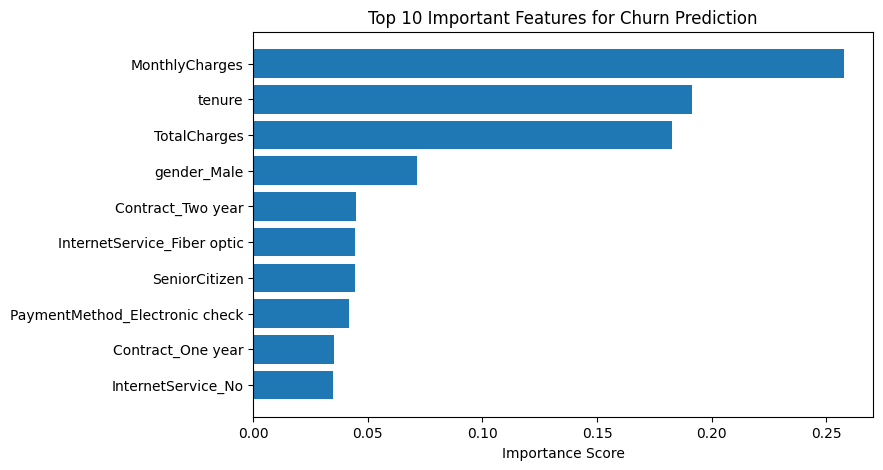

In [88]:
# Plot feature importance
plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Top 10 Important Features for Churn Prediction")
plt.xlabel("Importance Score")
plt.show()


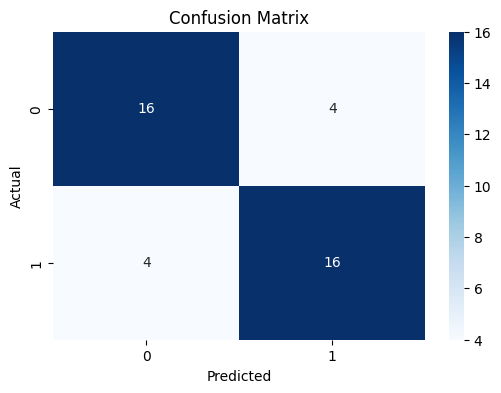

In [94]:
cm = confusion_matrix(y_pred_lr, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

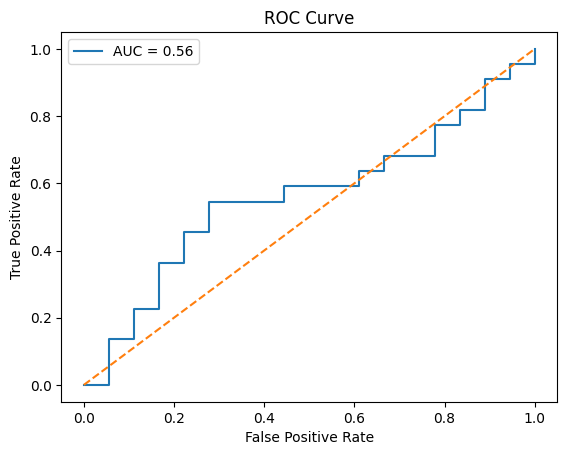

In [95]:
from sklearn.metrics import roc_curve, auc

# Get probability scores
y_prob = lr.predict_proba(X_test)[:,1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

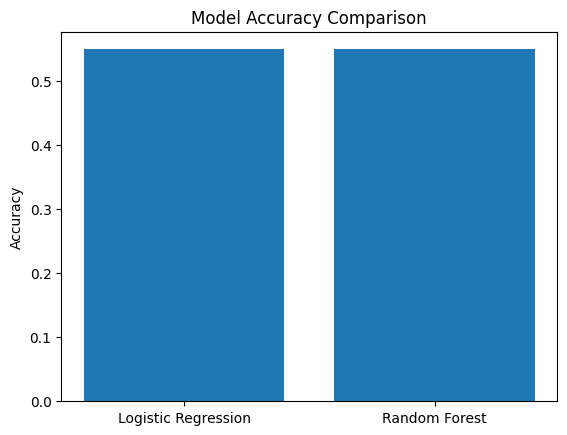

In [96]:
models = ["Logistic Regression", "Random Forest"]
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [97]:
print("Project completed!!")

Project completed!!
